# 4f: XGBoost Multi-Class Improvements


In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    balanced_accuracy_score, ConfusionMatrixDisplay, recall_score
)
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.under_sampling import RandomUnderSampler
import xgboost as xgb
from collections import Counter
from scipy.optimize import differential_evolution
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load data
df_train = pd.read_csv('../3_Data_Preprocessing/preprocessing_data/train_engineered.csv')
df_test = pd.read_csv('../3_Data_Preprocessing/preprocessing_data/test_engineered.csv')

with open('../3_Data_Preprocessing/preprocessing_data/feature_engineering_metadata.json') as f:
    metadata = json.load(f)

optimal_features = metadata['optimal_features']
all_features = metadata['all_features']

# Reconstruct label encoders
label_encoders = {}
for col, classes in metadata['label_encoder_classes'].items():
    le = LabelEncoder()
    le.classes_ = np.array(classes)
    label_encoders[col] = le

# Targets
y_train_4 = df_train['poverty_risk_score'].astype(int)
y_test_4 = df_test['poverty_risk_score'].astype(int)
y_train_bin = df_train['binary_target'].copy()
y_test_bin = df_test['binary_target'].copy()

class_names_4 = ['Stable', 'Near Poverty', 'Poverty', 'Deep Poverty']

X_train_opt = df_train[optimal_features].copy()
X_test_opt = df_test[optimal_features].copy()

print(f'Train: {X_train_opt.shape}, Test: {X_test_opt.shape}')
print(f'\n4-class distribution (train):')
for cls, name in enumerate(class_names_4):
    n = (y_train_4 == cls).sum()
    print(f'  {name}: {n:,} ({n/len(y_train_4)*100:.1f}%)')
print(f'\n4-class distribution (test):')
for cls, name in enumerate(class_names_4):
    n = (y_test_4 == cls).sum()
    print(f'  {name}: {n:,} ({n/len(y_test_4)*100:.1f}%)')

# ── Shared XGBoost parameters ──
xgb_params = dict(
    max_depth=6, learning_rate=0.1, n_estimators=500,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', early_stopping_rounds=30,
    random_state=42, n_jobs=-1
)

# ── Baseline 4-class: Undersample + XGBoost (reproduce from 4c) ──
rus = RandomUnderSampler(random_state=42)
X_tr_us, y_tr_us = rus.fit_resample(X_train_opt, y_train_4)
print(f'\nBaseline undersampled: {Counter(y_tr_us)}')

xgb_base = xgb.XGBClassifier(objective='multi:softmax', num_class=4, **xgb_params)
xgb_base.fit(X_tr_us, y_tr_us, eval_set=[(X_test_opt, y_test_4)], verbose=False)

y_pred_base = xgb_base.predict(X_test_opt)
base_f1 = f1_score(y_test_4, y_pred_base, average='macro')

print(f'\n{"="*70}')
print(f'BASELINE 4-CLASS (Undersample + XGBoost, {len(optimal_features)} features)')
print(f'{"="*70}')
print(classification_report(y_test_4, y_pred_base, target_names=class_names_4))
print(f'Macro F1: {base_f1:.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test_4, y_pred_base):.4f}')

# Store results for final comparison
results = {'Baseline\n(Undersample, 18 feat)': base_f1}

Train: (1469769, 18), Test: (304368, 18)

4-class distribution (train):
  Stable: 1,114,746 (75.8%)
  Near Poverty: 196,583 (13.4%)
  Poverty: 78,995 (5.4%)
  Deep Poverty: 79,445 (5.4%)

4-class distribution (test):
  Stable: 233,793 (76.8%)
  Near Poverty: 38,456 (12.6%)
  Poverty: 15,534 (5.1%)
  Deep Poverty: 16,585 (5.4%)

Baseline undersampled: Counter({0: 78995, 1: 78995, 2: 78995, 3: 78995})

BASELINE 4-CLASS (Undersample + XGBoost, 18 features)
              precision    recall  f1-score   support

      Stable       0.93      0.65      0.76    233793
Near Poverty       0.23      0.42      0.29     38456
     Poverty       0.15      0.33      0.20     15534
Deep Poverty       0.25      0.54      0.34     16585

    accuracy                           0.60    304368
   macro avg       0.39      0.48      0.40    304368
weighted avg       0.76      0.60      0.65    304368

Macro F1: 0.4003
Balanced Accuracy: 0.4827


---
## Change 1: Collapse to 3 Classes

3-class distribution (train):
  Stable: 1,114,746 (75.8%)
  Moderate Poverty: 275,578 (18.7%)
  Deep Poverty: 79,445 (5.4%)

CHANGE 1: 3-Class Collapse
                  precision    recall  f1-score   support

          Stable       0.92      0.68      0.78    233793
Moderate Poverty       0.33      0.54      0.41     53990
    Deep Poverty       0.23      0.62      0.34     16585

        accuracy                           0.65    304368
       macro avg       0.50      0.61      0.51    304368
    weighted avg       0.78      0.65      0.69    304368

Macro F1: 0.5105  (baseline 4-class: 0.4003)
Balanced Accuracy: 0.6132


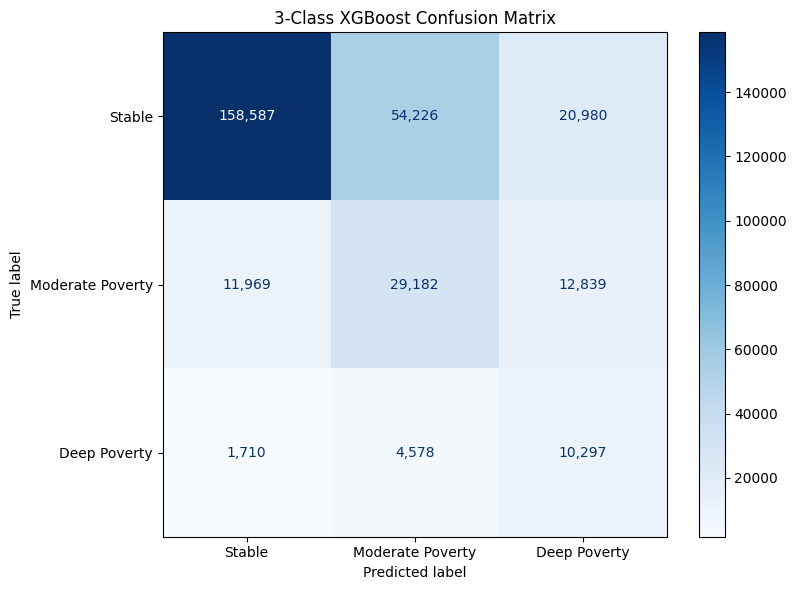

In [3]:
# Create 3-class target: merge Near Poverty (1) + Poverty (2) -> Moderate Poverty (1)
y_train_3 = y_train_4.replace({2: 1, 3: 2})  # 0->0, 1->1, 2->1, 3->2
y_test_3 = y_test_4.replace({2: 1, 3: 2})
class_names_3 = ['Stable', 'Moderate Poverty', 'Deep Poverty']

print('3-class distribution (train):')
for cls, name in enumerate(class_names_3):
    n = (y_train_3 == cls).sum()
    print(f'  {name}: {n:,} ({n/len(y_train_3)*100:.1f}%)')

# Undersample + train
rus_3 = RandomUnderSampler(random_state=42)
X_tr_us_3, y_tr_us_3 = rus_3.fit_resample(X_train_opt, y_train_3)

xgb_3class = xgb.XGBClassifier(objective='multi:softmax', num_class=3, **xgb_params)
xgb_3class.fit(X_tr_us_3, y_tr_us_3, eval_set=[(X_test_opt, y_test_3)], verbose=False)

y_pred_3 = xgb_3class.predict(X_test_opt)
f1_3class = f1_score(y_test_3, y_pred_3, average='macro')

print(f'\n{"="*70}')
print(f'CHANGE 1: 3-Class Collapse')
print(f'{"="*70}')
print(classification_report(y_test_3, y_pred_3, target_names=class_names_3))
print(f'Macro F1: {f1_3class:.4f}  (baseline 4-class: {base_f1:.4f})')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test_3, y_pred_3):.4f}')

# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_3, y_pred_3, display_labels=class_names_3,
    ax=ax, cmap='Blues', values_format=','
)
ax.set_title('3-Class XGBoost Confusion Matrix')
plt.tight_layout()
plt.show()

results['Change 1\n(3-Class Collapse)'] = f1_3class

---
## Change 2: Sample Weights Instead of Undersampling

In [4]:
# Sample weights: balanced class weighting on full dataset (no undersampling)
weights = compute_sample_weight('balanced', y_train_4)

print(f'Training on ALL data: {len(y_train_4):,} samples (vs {len(y_tr_us):,} undersampled)')
print(f'\nEffective class weights:')
for cls, name in enumerate(class_names_4):
    mask = y_train_4 == cls
    print(f'  {name}: weight = {weights[mask].mean():.3f}  (n = {mask.sum():,})')

xgb_weighted = xgb.XGBClassifier(objective='multi:softmax', num_class=4, **xgb_params)
xgb_weighted.fit(
    X_train_opt, y_train_4,
    sample_weight=weights,
    eval_set=[(X_test_opt, y_test_4)],
    verbose=False
)

y_pred_weighted = xgb_weighted.predict(X_test_opt)
f1_weighted = f1_score(y_test_4, y_pred_weighted, average='macro')

print(f'\n{"="*70}')
print(f'CHANGE 2: Sample Weights (No Undersampling, 1.47M rows)')
print(f'{"="*70}')
print(classification_report(y_test_4, y_pred_weighted, target_names=class_names_4))
print(f'Macro F1: {f1_weighted:.4f}  (baseline: {base_f1:.4f}, delta: {f1_weighted - base_f1:+.4f})')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test_4, y_pred_weighted):.4f}')

results['Change 2\n(Sample Weights)'] = f1_weighted

Training on ALL data: 1,469,769 samples (vs 315,980 undersampled)

Effective class weights:
  Stable: weight = 0.330  (n = 1,114,746)
  Near Poverty: weight = 1.869  (n = 196,583)
  Poverty: weight = 4.651  (n = 78,995)
  Deep Poverty: weight = 4.625  (n = 79,445)

CHANGE 2: Sample Weights (No Undersampling, 1.47M rows)
              precision    recall  f1-score   support

      Stable       0.93      0.65      0.77    233793
Near Poverty       0.23      0.42      0.30     38456
     Poverty       0.15      0.32      0.20     15534
Deep Poverty       0.25      0.54      0.34     16585

    accuracy                           0.60    304368
   macro avg       0.39      0.48      0.40    304368
weighted avg       0.76      0.60      0.66    304368

Macro F1: 0.4028  (baseline: 0.4003, delta: +0.0025)
Balanced Accuracy: 0.4835


---
## Change 3: Feature Engineering for Poverty Depth

In [5]:
def engineer_features(df, optimal_features):
    """Add interaction terms and restore dropped features for multi-class task."""
    X = df[optimal_features].copy()

    # Interaction terms
    X['earning_potential'] = df['WKHP'].fillna(0) * df['education_tier'].fillna(0)
    X['age_work_interaction'] = df['AGEP'] * df['WKHP'].fillna(0)

    # Restore features dropped during binary optimization
    X['disability_score'] = df['disability_score']
    X['SEX'] = df['SEX']
    X['NATIVITY'] = df['NATIVITY']
    X['WKL'] = df['WKL'].fillna(-1).astype(float)
    X['WRK'] = df['WRK'].fillna(-1).astype(float)

    # New raw ACS features
    X['COW'] = df['COW'].fillna(-1).astype(float)
    X['SCH'] = df['SCH'].fillna(-1).astype(float)

    return X

X_train_eng = engineer_features(df_train, optimal_features)
X_test_eng = engineer_features(df_test, optimal_features)

new_feats = [c for c in X_train_eng.columns if c not in optimal_features]
print(f'Engineered feature set: {X_train_eng.shape[1]} features (was {len(optimal_features)})')
print(f'New features added: {new_feats}')

# Undersample + train with engineered features
rus_eng = RandomUnderSampler(random_state=42)
X_tr_eng_us, y_tr_eng_us = rus_eng.fit_resample(X_train_eng, y_train_4)

xgb_eng = xgb.XGBClassifier(objective='multi:softmax', num_class=4, **xgb_params)
xgb_eng.fit(X_tr_eng_us, y_tr_eng_us, eval_set=[(X_test_eng, y_test_4)], verbose=False)

y_pred_eng = xgb_eng.predict(X_test_eng)
f1_eng = f1_score(y_test_4, y_pred_eng, average='macro')

print(f'\n{"="*70}')
print(f'CHANGE 3: Feature Engineering ({X_train_eng.shape[1]} features)')
print(f'{"="*70}')
print(classification_report(y_test_4, y_pred_eng, target_names=class_names_4))
print(f'Macro F1: {f1_eng:.4f}  (baseline: {base_f1:.4f}, delta: {f1_eng - base_f1:+.4f})')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test_4, y_pred_eng):.4f}')

# Show where the new features rank in importance
importance = pd.Series(xgb_eng.feature_importances_, index=X_train_eng.columns).sort_values(ascending=False)
print(f'\nNew feature importances (ranked among all {len(importance)} features):')
for feat in new_feats:
    rank = list(importance.index).index(feat) + 1
    print(f'  {feat}: importance = {importance[feat]:.4f} (rank {rank}/{len(importance)})')

results['Change 3\n(Feature Eng, 27 feat)'] = f1_eng

Engineered feature set: 27 features (was 18)
New features added: ['earning_potential', 'age_work_interaction', 'disability_score', 'SEX', 'NATIVITY', 'WKL', 'WRK', 'COW', 'SCH']

CHANGE 3: Feature Engineering (27 features)
              precision    recall  f1-score   support

      Stable       0.93      0.65      0.77    233793
Near Poverty       0.23      0.41      0.29     38456
     Poverty       0.15      0.35      0.21     15534
Deep Poverty       0.26      0.55      0.35     16585

    accuracy                           0.60    304368
   macro avg       0.39      0.49      0.40    304368
weighted avg       0.76      0.60      0.66    304368

Macro F1: 0.4043  (baseline: 0.4003, delta: +0.0040)
Balanced Accuracy: 0.4889

New feature importances (ranked among all 27 features):
  earning_potential: importance = 0.1016 (rank 2/27)
  age_work_interaction: importance = 0.0508 (rank 7/27)
  disability_score: importance = 0.0200 (rank 16/27)
  SEX: importance = 0.0238 (rank 14/27)
  NA

---
## Change 4: Per-Class Threshold Tuning

In [6]:
# Per-class threshold tuning via differential evolution
# Step 1: Split training data for threshold optimization
X_tune_tr, X_tune_val, y_tune_tr, y_tune_val = train_test_split(
    X_train_opt, y_train_4, test_size=0.2, random_state=42, stratify=y_train_4
)

# Step 2: Undersample training portion and train model
rus_tune = RandomUnderSampler(random_state=42)
X_tune_tr_us, y_tune_tr_us = rus_tune.fit_resample(X_tune_tr, y_tune_tr)

xgb_tune = xgb.XGBClassifier(objective='multi:softmax', num_class=4, **xgb_params)
xgb_tune.fit(X_tune_tr_us, y_tune_tr_us, eval_set=[(X_tune_val, y_tune_val)], verbose=False)

# Step 3: Get probabilities on validation set
proba_val = xgb_tune.predict_proba(X_tune_val)
print(f'Validation set: {len(y_tune_val):,} samples')
print(f'Default argmax Macro F1 on val: {f1_score(y_tune_val, proba_val.argmax(axis=1), average="macro"):.4f}')

# Step 4: Optimize class weights on validation set
def neg_macro_f1(weights, proba, y_true):
    adjusted = proba * np.array(weights)
    y_pred = adjusted.argmax(axis=1)
    return -f1_score(y_true, y_pred, average='macro')

print('\nOptimizing per-class weights on validation set...')
opt_result = differential_evolution(
    neg_macro_f1,
    bounds=[(0.5, 3.0)] * 4,
    args=(proba_val, y_tune_val),
    seed=42,
    maxiter=100,
    tol=1e-6
)

optimal_weights = opt_result.x
print(f'Optimal class weights: {[f"{w:.3f}" for w in optimal_weights]}')
print(f'Optimized Macro F1 on val: {-opt_result.fun:.4f}')

# Step 5: Apply weights to baseline model's test predictions
proba_test = xgb_base.predict_proba(X_test_opt)
y_pred_default = proba_test.argmax(axis=1)
adjusted_test = proba_test * optimal_weights
y_pred_tuned = adjusted_test.argmax(axis=1)

f1_tuned = f1_score(y_test_4, y_pred_tuned, average='macro')

print(f'\n{"="*70}')
print(f'CHANGE 4: Per-Class Threshold Tuning')
print(f'{"="*70}')
print(f'Class weights: Stable={optimal_weights[0]:.2f}, Near Poverty={optimal_weights[1]:.2f}, '
      f'Poverty={optimal_weights[2]:.2f}, Deep Poverty={optimal_weights[3]:.2f}')
print(classification_report(y_test_4, y_pred_tuned, target_names=class_names_4))
print(f'Macro F1: {f1_tuned:.4f}  (baseline: {base_f1:.4f}, delta: {f1_tuned - base_f1:+.4f})')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test_4, y_pred_tuned):.4f}')

results['Change 4\n(Threshold Tuning)'] = f1_tuned

Validation set: 293,954 samples
Default argmax Macro F1 on val: 0.4094

Optimizing per-class weights on validation set...
Optimal class weights: ['2.947', '1.475', '1.035', '0.687']
Optimized Macro F1 on val: 0.4458

CHANGE 4: Per-Class Threshold Tuning
Class weights: Stable=2.95, Near Poverty=1.47, Poverty=1.03, Deep Poverty=0.69
              precision    recall  f1-score   support

      Stable       0.88      0.83      0.85    233793
Near Poverty       0.28      0.35      0.31     38456
     Poverty       0.20      0.23      0.21     15534
Deep Poverty       0.35      0.38      0.36     16585

    accuracy                           0.71    304368
   macro avg       0.43      0.45      0.43    304368
weighted avg       0.74      0.71      0.72    304368

Macro F1: 0.4346  (baseline: 0.4003, delta: +0.0343)
Balanced Accuracy: 0.4455


---
## Change 5: Hierarchical Classification

In [7]:
# ── Stage 1: Binary model (Stable vs At-Risk) ──
rus_bin = RandomUnderSampler(random_state=42)
X_tr_bin_us, y_tr_bin_us = rus_bin.fit_resample(X_train_opt, y_train_bin)

xgb_binary = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth=6, learning_rate=0.1, n_estimators=500,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', early_stopping_rounds=30,
    random_state=42, n_jobs=-1
)
xgb_binary.fit(X_tr_bin_us, y_tr_bin_us,
               eval_set=[(X_test_opt, y_test_bin)], verbose=False)

y_pred_binary = xgb_binary.predict(X_test_opt)
print(f'Stage 1 — Binary model:')
print(f'  Macro F1: {f1_score(y_test_bin, y_pred_binary, average="macro"):.4f}')
print(f'  At-Risk Recall: {recall_score(y_test_bin, y_pred_binary, pos_label=1):.4f}')
print(f'  Predicted At-Risk: {(y_pred_binary == 1).sum():,} / {len(y_pred_binary):,}')

# ── Stage 2: Severity model (among at-risk: Near Poverty vs Poverty vs Deep Poverty) ──
at_risk_mask_train = y_train_4.isin([1, 2, 3])
X_tr_severity = X_train_opt[at_risk_mask_train]
y_tr_severity = y_train_4[at_risk_mask_train].copy()

# Remap: 1->0, 2->1, 3->2 for the 3-class severity model
severity_map = {1: 0, 2: 1, 3: 2}
y_tr_severity_mapped = y_tr_severity.map(severity_map)

print(f'\nStage 2 — Severity training data: {len(y_tr_severity):,} at-risk samples')
print(f'  Distribution: {Counter(y_tr_severity_mapped)}')

rus_sev = RandomUnderSampler(random_state=42)
X_tr_sev_us, y_tr_sev_us = rus_sev.fit_resample(X_tr_severity, y_tr_severity_mapped)

# Use at-risk test samples for early stopping
at_risk_mask_test = y_test_4.isin([1, 2, 3])
X_test_severity = X_test_opt[at_risk_mask_test]
y_test_severity_mapped = y_test_4[at_risk_mask_test].map(severity_map)

xgb_severity = xgb.XGBClassifier(
    objective='multi:softmax', num_class=3,
    max_depth=6, learning_rate=0.1, n_estimators=500,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', early_stopping_rounds=30,
    random_state=42, n_jobs=-1
)
xgb_severity.fit(X_tr_sev_us, y_tr_sev_us,
                 eval_set=[(X_test_severity, y_test_severity_mapped)], verbose=False)

# ── Combine: hierarchical prediction ──
y_pred_hier = np.zeros(len(y_test_4), dtype=int)  # Default: Stable (0)
at_risk_pred_mask = y_pred_binary == 1

if at_risk_pred_mask.any():
    severity_preds = xgb_severity.predict(X_test_opt[at_risk_pred_mask])
    # Map back: 0->1, 1->2, 2->3
    severity_reverse = {0: 1, 1: 2, 2: 3}
    y_pred_hier[at_risk_pred_mask] = np.vectorize(severity_reverse.get)(severity_preds)

f1_hier = f1_score(y_test_4, y_pred_hier, average='macro')

print(f'\n{"="*70}')
print(f'CHANGE 5: Hierarchical Classification (Binary -> Severity)')
print(f'{"="*70}')
print(classification_report(y_test_4, y_pred_hier, target_names=class_names_4))
print(f'Macro F1: {f1_hier:.4f}  (baseline: {base_f1:.4f}, delta: {f1_hier - base_f1:+.4f})')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test_4, y_pred_hier):.4f}')

results['Change 5\n(Hierarchical)'] = f1_hier

Stage 1 — Binary model:
  Macro F1: 0.6874
  At-Risk Recall: 0.7735
  Predicted At-Risk: 120,574 / 304,368

Stage 2 — Severity training data: 355,023 at-risk samples
  Distribution: Counter({0: 196583, 2: 79445, 1: 78995})

CHANGE 5: Hierarchical Classification (Binary -> Severity)
              precision    recall  f1-score   support

      Stable       0.91      0.72      0.80    233793
Near Poverty       0.25      0.36      0.30     38456
     Poverty       0.15      0.32      0.21     15534
Deep Poverty       0.26      0.53      0.35     16585

    accuracy                           0.64    304368
   macro avg       0.40      0.48      0.41    304368
weighted avg       0.76      0.64      0.68    304368

Macro F1: 0.4145  (baseline: 0.4003, delta: +0.0142)
Balanced Accuracy: 0.4818


---
## Combined: Best Strategies Together

In [8]:
# ── Combined: Sample Weights + Engineered Features ──
weights_combined = compute_sample_weight('balanced', y_train_4)

xgb_combined = xgb.XGBClassifier(objective='multi:softmax', num_class=4, **xgb_params)
xgb_combined.fit(
    X_train_eng, y_train_4,
    sample_weight=weights_combined,
    eval_set=[(X_test_eng, y_test_4)],
    verbose=False
)

y_pred_combined = xgb_combined.predict(X_test_eng)
f1_combined = f1_score(y_test_4, y_pred_combined, average='macro')

print(f'Combined (Sample Weights + Engineered Features):')
print(f'  Macro F1: {f1_combined:.4f}  (baseline: {base_f1:.4f}, delta: {f1_combined - base_f1:+.4f})')

# ── Add threshold tuning on top ──
# Split training data for threshold optimization
X_comb_tr, X_comb_val, y_comb_tr, y_comb_val = train_test_split(
    X_train_eng, y_train_4, test_size=0.2, random_state=42, stratify=y_train_4
)

weights_comb_tr = compute_sample_weight('balanced', y_comb_tr)

xgb_comb_tune = xgb.XGBClassifier(objective='multi:softmax', num_class=4, **xgb_params)
xgb_comb_tune.fit(
    X_comb_tr, y_comb_tr,
    sample_weight=weights_comb_tr,
    eval_set=[(X_comb_val, y_comb_val)],
    verbose=False
)

proba_comb_val = xgb_comb_tune.predict_proba(X_comb_val)
print(f'\nOptimizing thresholds on combined model...')
opt_comb = differential_evolution(
    neg_macro_f1,
    bounds=[(0.5, 3.0)] * 4,
    args=(proba_comb_val, y_comb_val),
    seed=42, maxiter=100, tol=1e-6
)
comb_weights = opt_comb.x
print(f'Optimal weights: {[f"{w:.3f}" for w in comb_weights]}')

# Apply to full combined model's test predictions
proba_comb_test = xgb_combined.predict_proba(X_test_eng)
y_pred_comb_tuned = (proba_comb_test * comb_weights).argmax(axis=1)
f1_comb_tuned = f1_score(y_test_4, y_pred_comb_tuned, average='macro')

print(f'\n{"="*70}')
print(f'COMBINED: Sample Weights + Feature Eng + Threshold Tuning')
print(f'{"="*70}')
print(classification_report(y_test_4, y_pred_comb_tuned, target_names=class_names_4))
print(f'Macro F1: {f1_comb_tuned:.4f}  (baseline: {base_f1:.4f}, delta: {f1_comb_tuned - base_f1:+.4f})')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test_4, y_pred_comb_tuned):.4f}')

results['Combined\n(Weights+Feat+Thresh)'] = f1_comb_tuned

Combined (Sample Weights + Engineered Features):
  Macro F1: 0.4073  (baseline: 0.4003, delta: +0.0071)

Optimizing thresholds on combined model...
Optimal weights: ['2.969', '1.496', '1.003', '0.634']

COMBINED: Sample Weights + Feature Eng + Threshold Tuning
              precision    recall  f1-score   support

      Stable       0.88      0.83      0.85    233793
Near Poverty       0.29      0.38      0.33     38456
     Poverty       0.21      0.23      0.22     15534
Deep Poverty       0.39      0.37      0.38     16585

    accuracy                           0.72    304368
   macro avg       0.44      0.45      0.44    304368
weighted avg       0.74      0.72      0.73    304368

Macro F1: 0.4432  (baseline: 0.4003, delta: +0.0429)
Balanced Accuracy: 0.4503


---
## Final Comparison

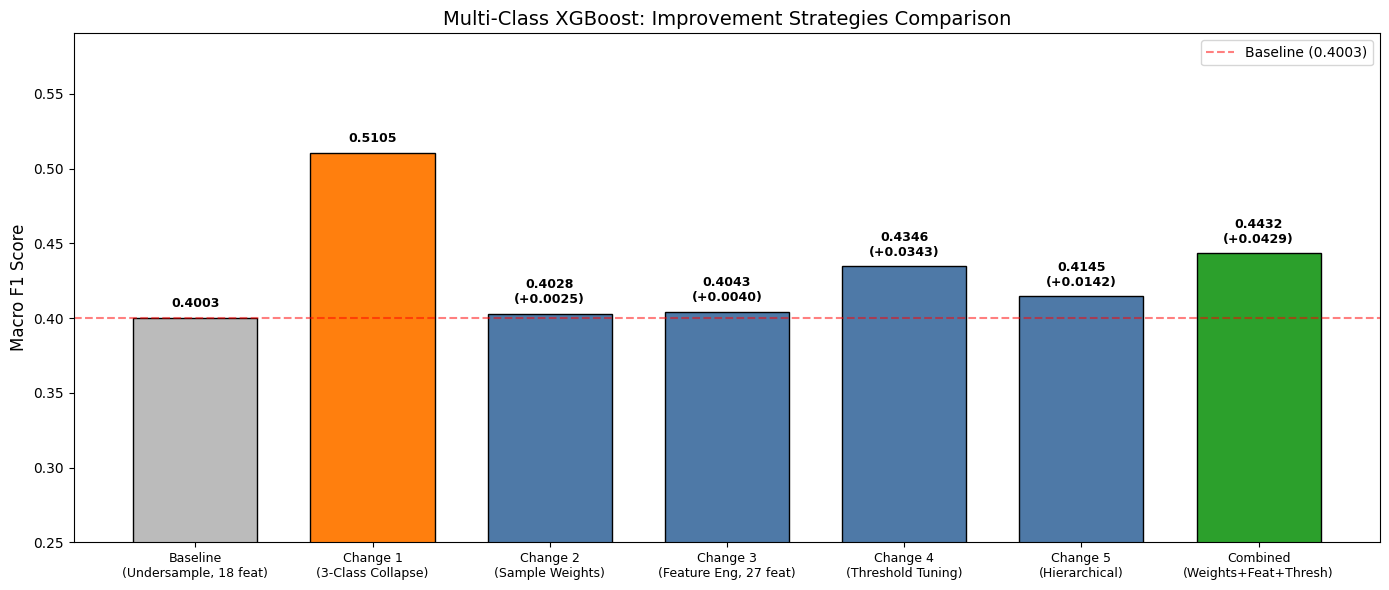

SUMMARY: Multi-Class Improvement Strategies
Approach                                      Macro F1     Delta       
---------------------------------------------------------------------
Baseline (Undersample, 18 feat)               0.4003       —           
Change 1 (3-Class Collapse)                   0.5105       +0.1102     
Change 2 (Sample Weights)                     0.4028       +0.0025     
Change 3 (Feature Eng, 27 feat)               0.4043       +0.0040     
Change 4 (Threshold Tuning)                   0.4346       +0.0343     
Change 5 (Hierarchical)                       0.4145       +0.0142     
Combined (Weights+Feat+Thresh)                0.4432       +0.0429     
---------------------------------------------------------------------

Note: Change 1 (3-Class) is a different task and not directly comparable to the 4-class baseline.
All other changes are evaluated on the same 4-class holdout set.


In [9]:
# Final comparison chart
fig, ax = plt.subplots(figsize=(14, 6))

labels = list(results.keys())
f1_scores = list(results.values())

# Color: gray for baseline, blue for individual changes, green for combined
colors = []
for label in labels:
    if 'Baseline' in label:
        colors.append('#bbb')
    elif 'Combined' in label:
        colors.append('#2ca02c')
    elif 'Change 1' in label:
        colors.append('#ff7f0e')  # orange (different task: 3-class)
    else:
        colors.append('#4e79a7')

bars = ax.bar(range(len(labels)), f1_scores, color=colors, edgecolor='black', width=0.7)

# Add value labels on bars
for i, (f1_val, label) in enumerate(zip(f1_scores, labels)):
    delta = f1_val - base_f1
    delta_str = f'\n({delta:+.4f})' if 'Baseline' not in label and 'Change 1' not in label else ''
    ax.text(i, f1_val + 0.005, f'{f1_val:.4f}{delta_str}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9, ha='center')
ax.set_ylabel('Macro F1 Score', fontsize=12)
ax.set_title('Multi-Class XGBoost: Improvement Strategies Comparison', fontsize=14)
ax.set_ylim(0.25, max(f1_scores) + 0.08)
ax.axhline(y=base_f1, color='red', linestyle='--', alpha=0.5, label=f'Baseline ({base_f1:.4f})')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('../3_Data_Preprocessing/preprocessing_data/multiclass_improvements_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print('=' * 80)
print('SUMMARY: Multi-Class Improvement Strategies')
print('=' * 80)
print(f'{"Approach":<45} {"Macro F1":<12} {"Delta":<12}')
print('-' * 69)
for label, f1_val in results.items():
    clean_label = label.replace('\n', ' ')
    delta = f1_val - base_f1
    delta_str = f'{delta:+.4f}' if 'Baseline' not in label else '—'
    print(f'{clean_label:<45} {f1_val:<12.4f} {delta_str:<12}')
print('-' * 69)
print(f'\nNote: Change 1 (3-Class) is a different task and not directly comparable to the 4-class baseline.')
print(f'All other changes are evaluated on the same 4-class holdout set.')